# Загрузка данных и распределение по фреймам

In [16]:
import pandas as pd
import numpy as np

# Настройка показа данных
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

In [17]:
df = pd.read_excel('alak_example.xlsx')
print(df)

      Месяц  Скважина P забойное - расчетное (атм) Н д (м)  Q нефти (т/сут)  Q жидкости (м3/сут)  Обводненность %
0    Январь         3                        122.0     847               12                  160             91.1
1    Январь         8                        113.8     123               11                  157             91.6
2    Январь        18        пакер или ОРД без ТМС     ОРД                6                   56             87.0
3   Февраль         3                        121.6     847                9                  157             93.1
4   Февраль         8                        111.9     108                9                  158             93.5
5   Февраль        18                         57.9   пакер                3                   58             93.1
6      Март         3                        121.5     775                9                  153             92.9
7      Март         8                        116.9     112                6             

In [18]:
# Проверка данных на соответствие

df['Скважина'] = df['Скважина'].astype(str)


In [21]:
# Распределение данных по скважинам

for well in df['Скважина'].unique():
    globals()[f'df_{well}'] = df[df['Скважина'] == well].reset_index(drop=True)
    print(f"Создан DataFrame: df_{well} (размер: {globals()[f'df_{well}'].shape})")

Создан DataFrame: df_3 (размер: (7, 7))
Создан DataFrame: df_8 (размер: (7, 7))
Создан DataFrame: df_18 (размер: (7, 7))


In [ ]:
# Смотрим данные

df_3['P забойное - расчетное (атм)'] = pd.to_numeric(df_3['P забойное - расчетное (атм)'], errors='coerce')
print(f'По скважине 3: \n {df_3}')

df_8['P забойное - расчетное (атм)'] = pd.to_numeric(df_8['P забойное - расчетное (атм)'], errors='coerce')
print(f'По скважине 8: \n {df_8}')

df_18['P забойное - расчетное (атм)'] = pd.to_numeric(df_18['P забойное - расчетное (атм)'], errors='coerce')
print(f'По скважине 18: \n {df_18}')

По скважине 3: 
      Месяц Скважина  P забойное - расчетное (атм) Н д (м)  Q нефти (т/сут)  Q жидкости (м3/сут)  Обводненность %
0   Январь        3                         122.0     847               12                  160             91.1
1  Февраль        3                         121.6     847                9                  157             93.1
2     Март        3                         121.5     775                9                  153             92.9
3   Апрель        3                         120.3     696                8                  158             94.2
4      Май        3                         119.5     696                9                  150             93.0
5     Июнь        3                         119.6     634                8                  148             93.2
6     Июль        3                         152.0    1157               18                  380             94.4
По скважине 8: 
      Месяц Скважина  P забойное - расчетное (атм) Н д (м)  Q н

# Построим графики по каждому столбцу каждой скважины

In [25]:
import matplotlib.pyplot as plt

## По 3 скважине

     Месяц Скважина  P забойное - расчетное (атм) Н д (м)  Q нефти (т/сут)  Q жидкости (м3/сут)  Обводненность %
0   Январь        3                         122.0     847               12                  160             91.1
1  Февраль        3                         121.6     847                9                  157             93.1
2     Март        3                         121.5     775                9                  153             92.9
3   Апрель        3                         120.3     696                8                  158             94.2
4      Май        3                         119.5     696                9                  150             93.0
5     Июнь        3                         119.6     634                8                  148             93.2
6     Июль        3                         152.0    1157               18                  380             94.4


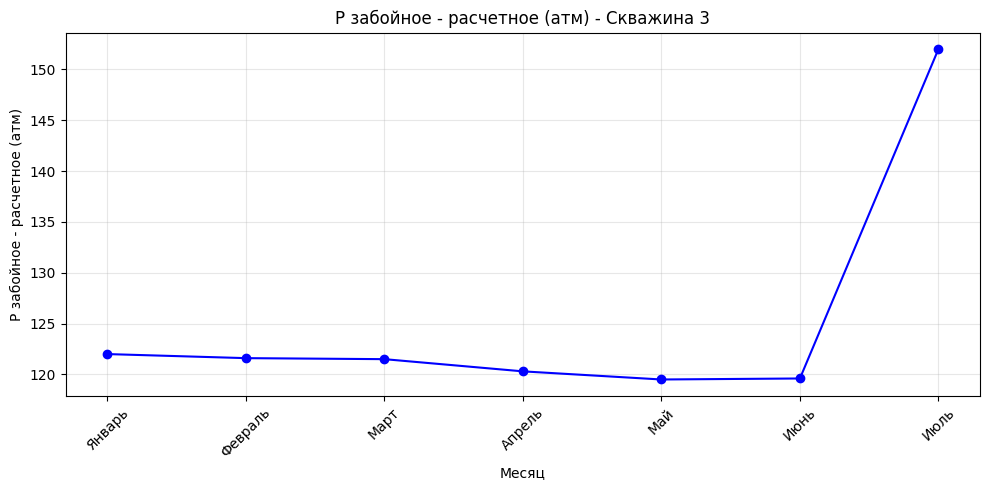

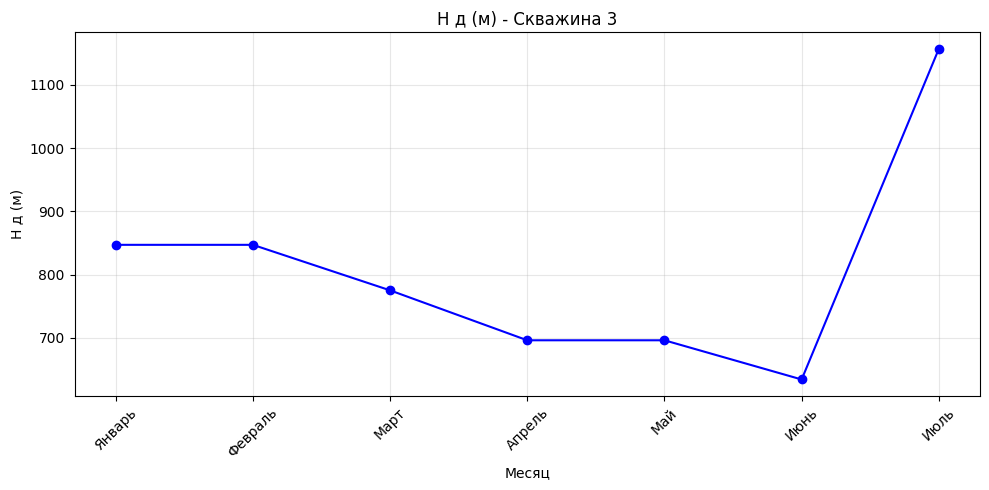

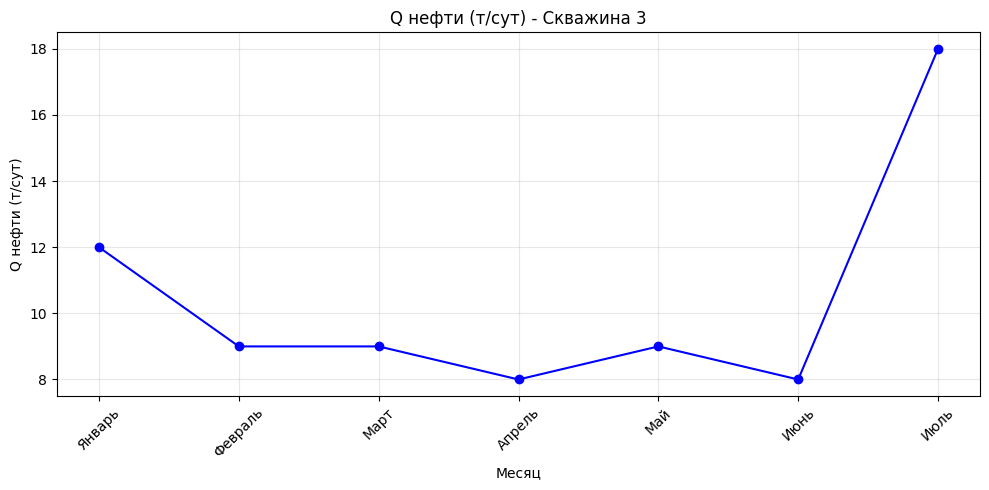

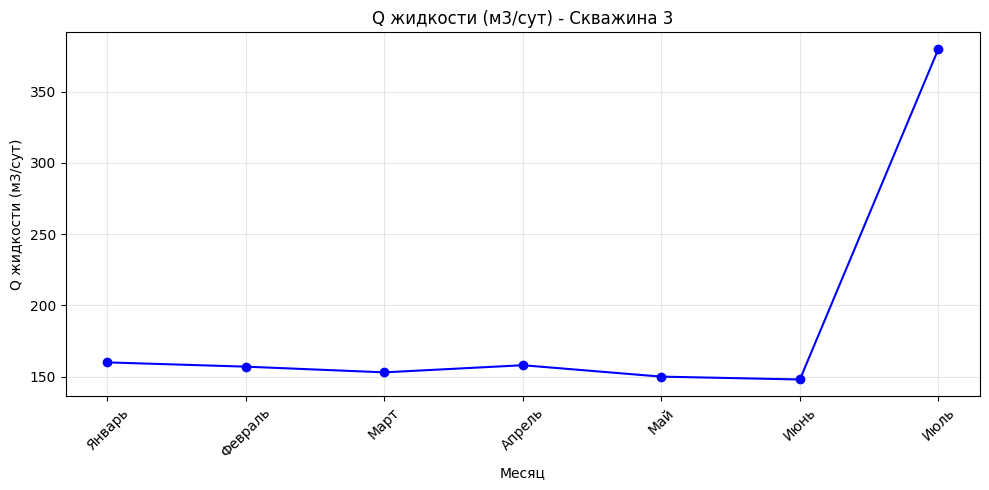

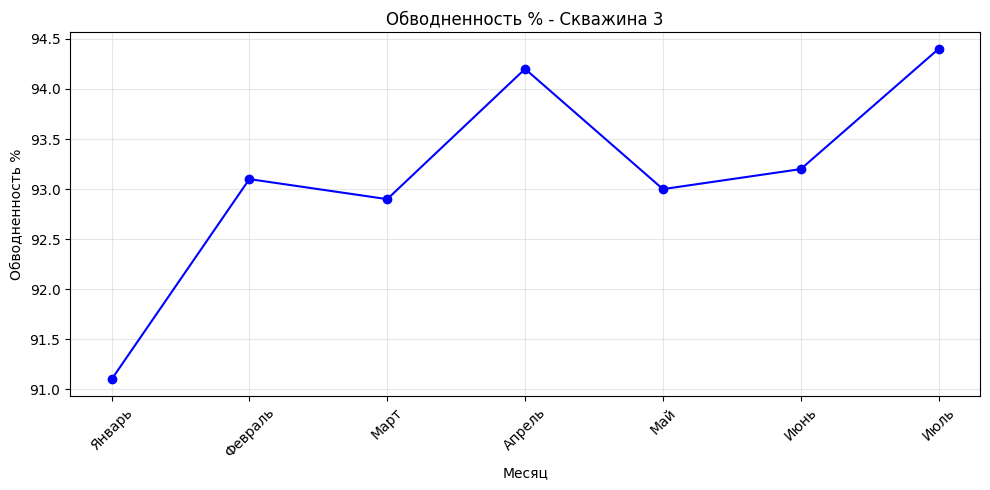

In [42]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# список столбцов для построения графиков
columns_to_plot = [
    'P забойное - расчетное (атм)',
    'Н д (м)',
    'Q нефти (т/сут)',
    'Q жидкости (м3/сут)',
    'Обводненность %'
]

print(df_3)

for col in columns_to_plot:
    plt.figure(figsize=(10, 5))
    plt.plot(df_3['Месяц'], df_3[col], marker='o', linestyle='-', color='blue')

    plt.title(f'{col} - Скважина 3')
    plt.ylabel(col)
    plt.xlabel('Месяц')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## По 8 скважине

     Месяц Скважина  P забойное - расчетное (атм) Н д (м)  Q нефти (т/сут)  Q жидкости (м3/сут)  Обводненность %
0   Январь        8                         113.8     123               11                  157             91.6
1  Февраль        8                         111.9     108                9                  158             93.5
2     Март        8                         116.9     112                6                  159             95.8
3   Апрель        8                         118.9      51                2                   10             75.9
4      Май        8                         112.9      51                8                  156             94.0
5     Июнь        8                         110.9      82                6                  156             95.2
6     Июль        8                         109.8      95                9                  156             93.0


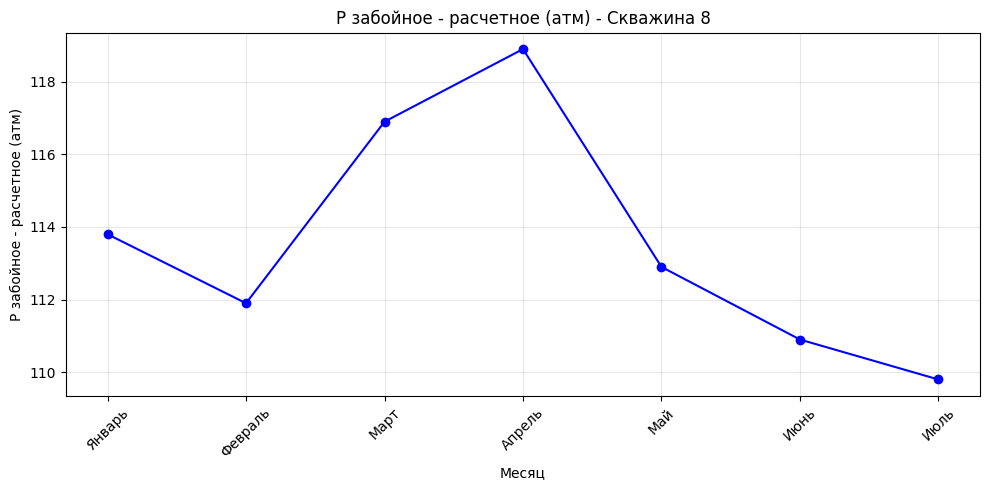

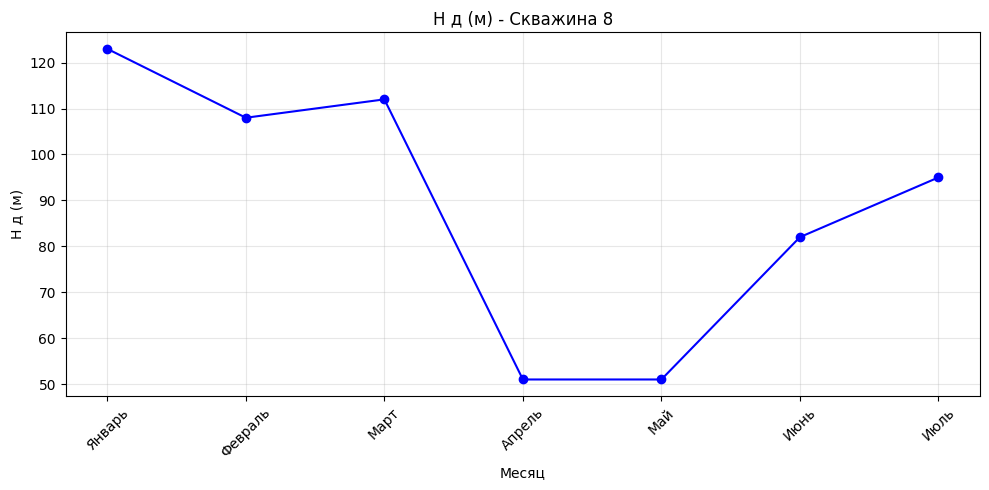

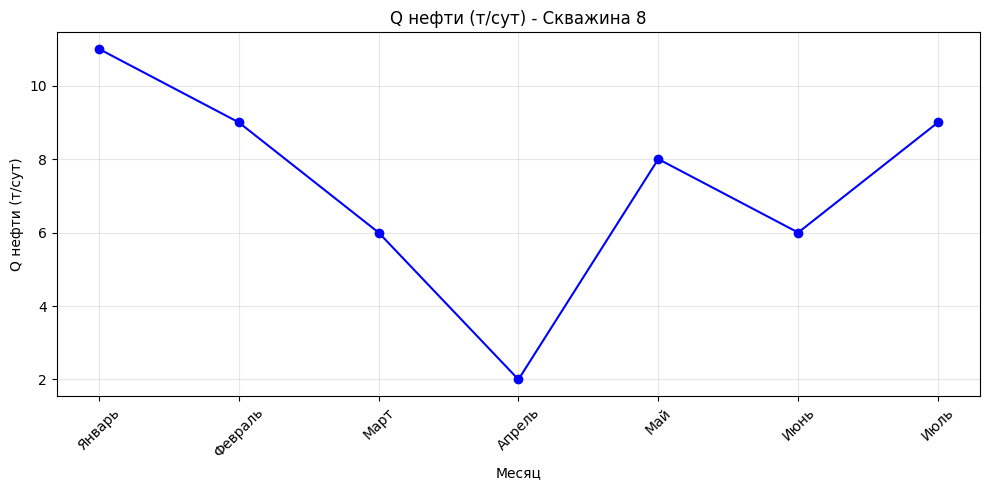

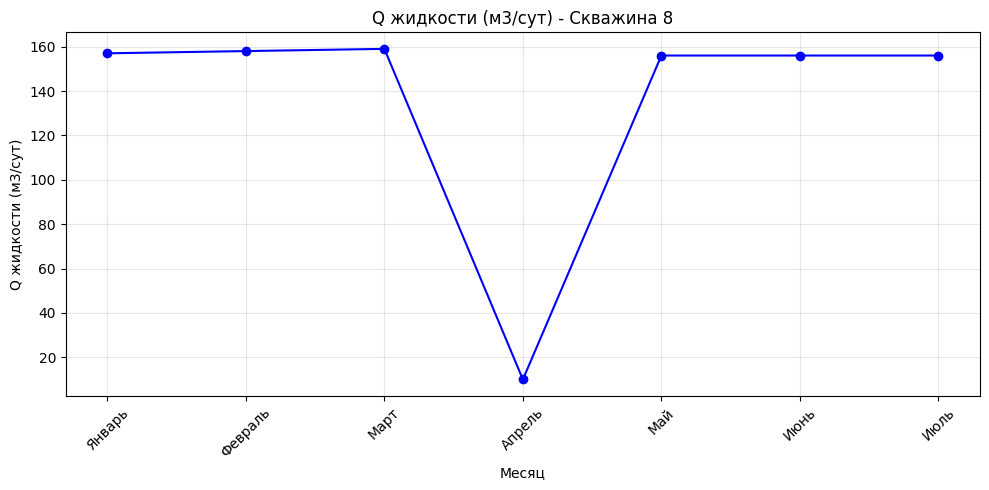

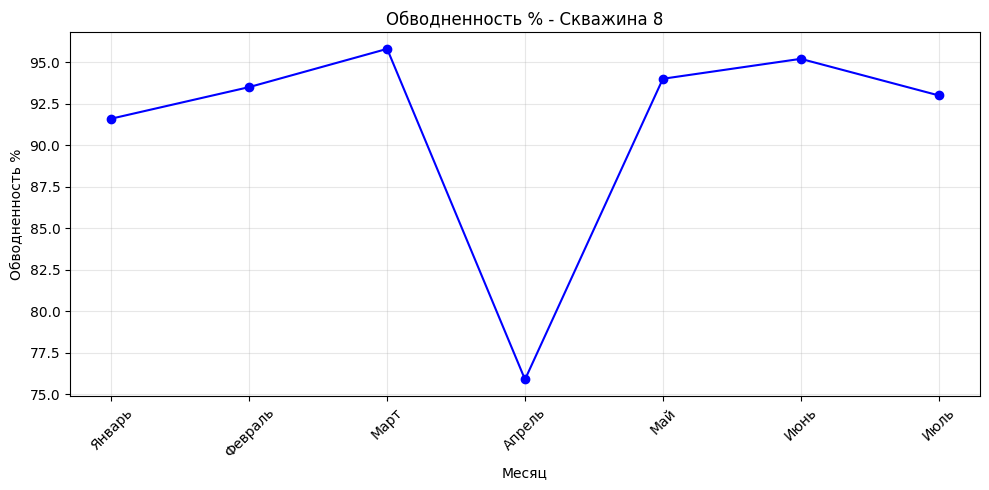

In [40]:
# список столбцов для построения графиков
columns_to_plot = [
    'P забойное - расчетное (атм)',
    'Н д (м)',
    'Q нефти (т/сут)',
    'Q жидкости (м3/сут)',
    'Обводненность %'
]

print(df_8)

for col in columns_to_plot:
    plt.figure(figsize=(10, 5))
    plt.plot(df_8['Месяц'], df_8[col], marker='o', linestyle='-', color='blue')
    plt.title(f'{col} - Скважина 8')
    plt.ylabel(col)
    plt.xlabel('Месяц')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## По 18 скважине

     Месяц Скважина  P забойное - расчетное (атм) Н д (м)  Q нефти (т/сут)  Q жидкости (м3/сут)  Обводненность %
0   Январь       18                           NaN     ОРД                6                   56             87.0
1  Февраль       18                          57.9   пакер                3                   58             93.1
2     Март       18                          57.8   пакер                4                   58             92.4
3   Апрель       18                          62.8   пакер               26                  465             93.3
4      Май       18                          57.8   пакер                4                   58             91.4
5     Июнь       18                          57.9   пакер                3                   58             93.1
6     Июль       18                          55.9   пакер                3                   58             92.9


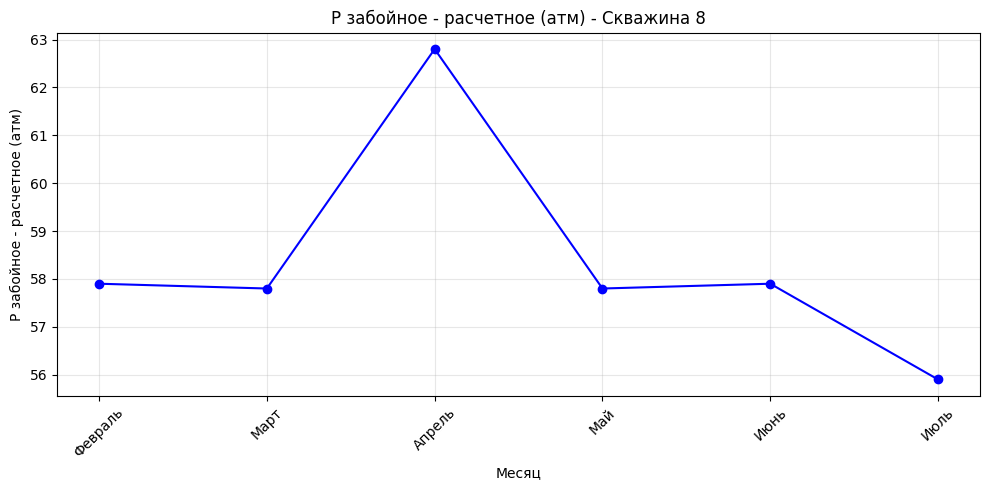

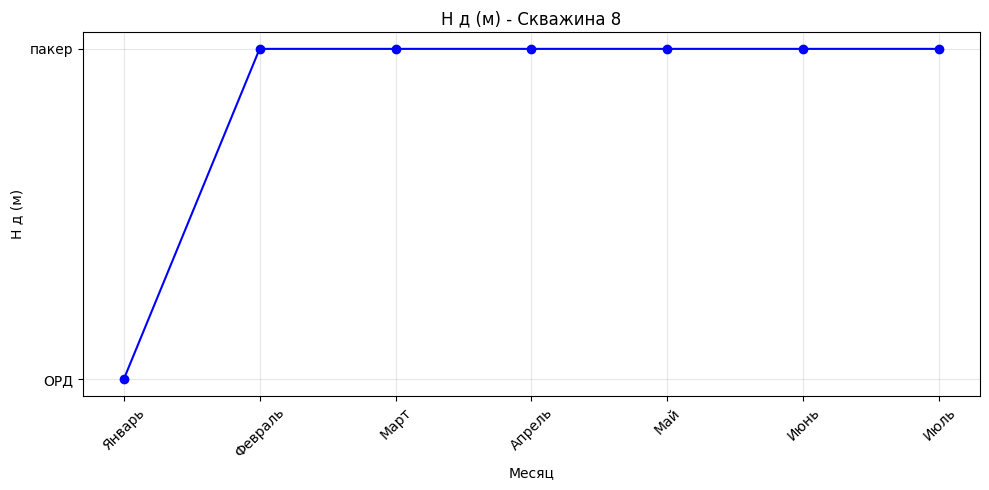

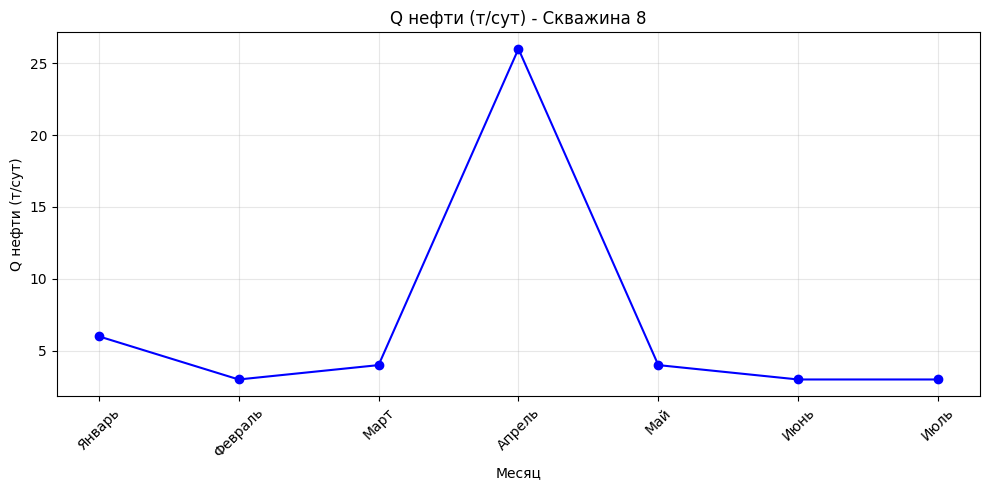

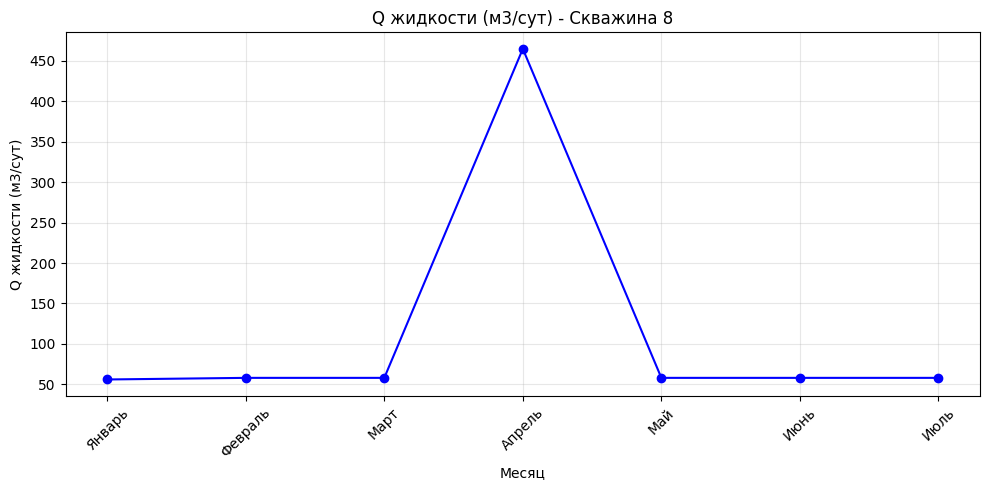

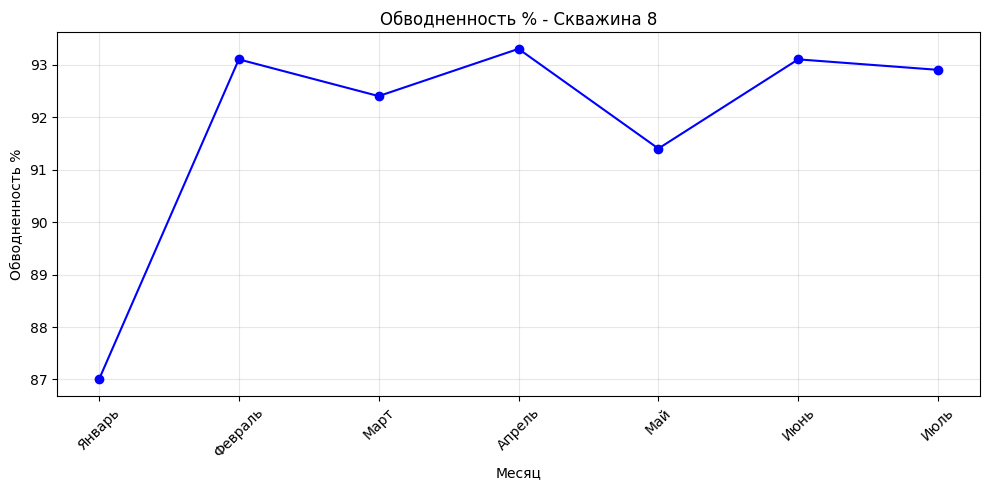

In [41]:
# список столбцов для построения графиков
columns_to_plot = [
    'P забойное - расчетное (атм)',
    'Н д (м)',
    'Q нефти (т/сут)',
    'Q жидкости (м3/сут)',
    'Обводненность %'
]

print(df_18)

for col in columns_to_plot:
    plt.figure(figsize=(10, 5))
    plt.plot(df_18['Месяц'], df_18[col], marker='o', linestyle='-', color='blue')
    plt.title(f'{col} - Скважина 8')
    plt.ylabel(col)
    plt.xlabel('Месяц')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Прогнозирование параметров

## Пример с линейной регрессией

In [60]:
from sklearn.linear_model import LinearRegression

In [64]:
# выберем параметр для предсказания
param = 'Обводненность %'

# закодируем месяц как число (1=Январь, 2=Февраль, ...)
month_map = {'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4, 'Май': 5, 'Июнь': 6, 'Июль': 7}
df_3['Месяц_число'] = df_3['Месяц'].map(month_map)

# Удаляем строки с NaN в нужном столбце
df_clean = df_3.dropna(subset=[param])

X = df_clean[['Месяц_число']]
y = df_clean[param]

In [65]:
# возьмем модель линейной регрессии из sklearn
model = LinearRegression()
model.fit(X, y)

# сделаем один прогноз на август
august_pred = model.predict([[8]])
print(f"Прогноз {param} на август: {august_pred[0 ]:.1f}%")

Прогноз Обводненность % на август: 94.6%


/Users/evgeny/Documents/Глубинное/project/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
